##FOUNDATION OF MACHINE LEARNING AND EDA ASSIGNMENT


Question 1 : What is the difference between AI, ML, DL, and Data Science? Provide a
brief explanation of each.

Answer:

1. AI (Artificial Intelligence): Making machines actg smart
- Example: Siri, Alexa

2. ML (Machine Learning): Machines learn from data.
- Example: Netflix recommending movies.

3. DL (Deep Learning): uses neural networks for complex tasks.
- Example: Face recognition in phones.

4. Data Science: Analyzing data to get insights and make dicisions
- Example: Companies studying sales data to improve business.


Relation:
AI -> ML -> DL, and Data Science uses them all for data-driven solutions

- Scope:
- AI: Big scope in automation, robotics, chatbots. Jobs: AI Engineer

- ML: Used in predictions, recommendations, fraud detection. Jobs: ML Engineer

- DL: Scope in image, speech, and self-driving tech. Jobs: Deep Learning Engineer

- Data Science: High demand in every industry for insights. Jobs: Data Scientist



Question 2: Explain overfitting and underfitting in ML. How can you detect and prevent
them?


Answer:

- Overfitting: Model learns too much from training data (including noise) → performs well on training data but poorly on new data.

- Underfitting: Model is too simple → performs poorly on both training and test data.

-> Detection:

- Compare training vs test accuracy.

- Big gap → Overfitting

- Both low → Underfitting

-> Prevention:

- Bias-Variance Tradeoff: Balance model complexity.

- Cross-Validation: Test model on different data splits.

- Regularization: Use techniques like L1 (Lasso), L2 (Ridge) to reduce overfitting.

Question 3: How would you handle missing values in a dataset? Explain at least three
methods with examples.

Answer:

1. Deletion: Remove rows or columns with missing values.
- Example: df.dropna() in Python.

2. Mean/Median Imputation: Fill missing values with the column’s mean or median.
- Example: df['Age'].fillna(df['Age'].mean())

3. Predictive Modeling: Predict missing values using models (like regression or KNN).
- Example: Use other features to predict missing Age.

Question 4:What is an imbalanced dataset? Describe two techniques to handle it
(theoretical + practical).

Answer:

Imbalanced Dataset: When one class has much more data than another (e.g., 90% normal, 10% fraud).
→ Model becomes biased toward the majority class.

-> Techniques to Handle:

1. SMOTE (Synthetic Minority Over-sampling Technique):

- Creates new synthetic samples of the minority class.
- Practical: from imblearn.over_sampling import SMOTE

2. Random Under/Oversampling:

- Oversampling: Duplicate minority data.

- Undersampling: Remove some majority data.
- Practical: RandomOverSampler() or RandomUnderSampler()

3.(Optional) Class Weights:

- Give higher weight to minority class in models.
- Example: model.fit(X, y, class_weight='balanced')


Question 5: Why is feature scaling important in ML? Compare Min-Max scaling and
Standardization.

Answer:

Feature Scaling:
Makes all features equal in range so that no variable dominates others.
- Important for algorithms like KNN, SVM, Gradient Descent that depend on distance or magnitude.

1. Min-Max Scaling (Normalization):

Scales data to a fixed range [0, 1].

- Formula: (x - min) / (max - min)

- Example: Good for image data or bounded features.

2. Standardization (Z-score Scaling):

Centers data with mean = 0, std = 1.

- Formula: (x - mean) / std

- Example: Best for algorithms assuming normal distribution (e.g., Linear Regression, SVM).

Question 6: Compare Label Encoding and One-Hot Encoding. When would you prefer
one over the other?

Answer:

1. Label Encoding:
Converts categories into numeric labels (0, 1, 2, …).
- Example: Low=0, Medium=1, High=2
- Use when order matters (Ordinal data).

2. One-Hot Encoding:
Creates separate binary columns for each category.
- Example: Red → [1,0,0], Blue → [0,1,0], Green → [0,0,1]
- Use when no order exists (Nominal data).

Question 7: Google Play Store Dataset
a). Analyze the relationship between app categories and ratings. Which categories have the
highest/lowest average ratings, and what could be the possible reasons?



Answer:

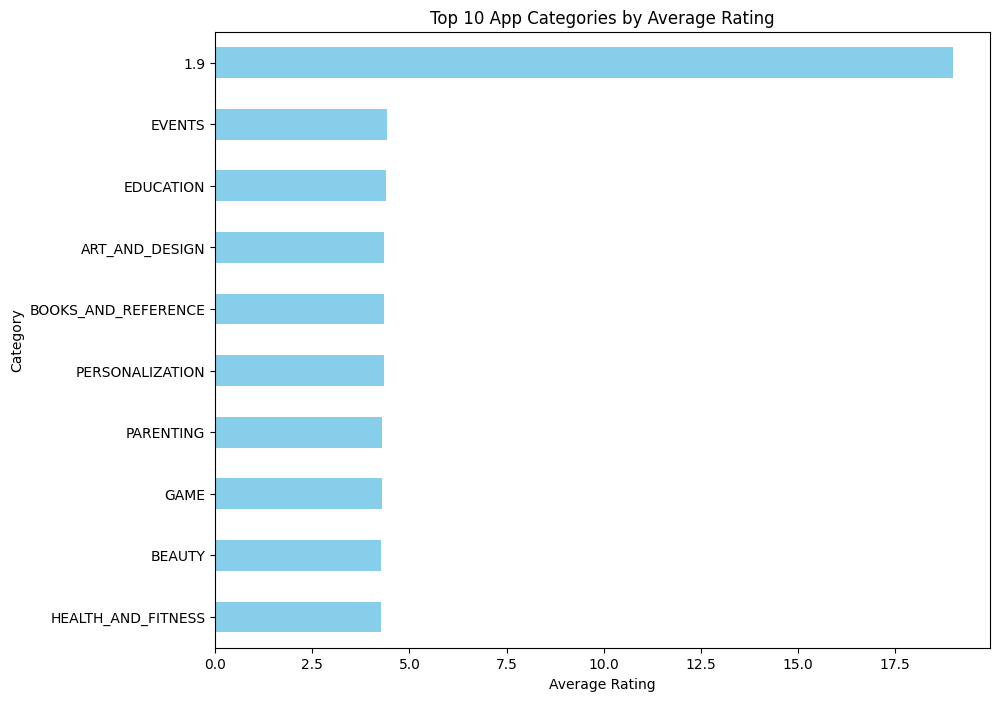

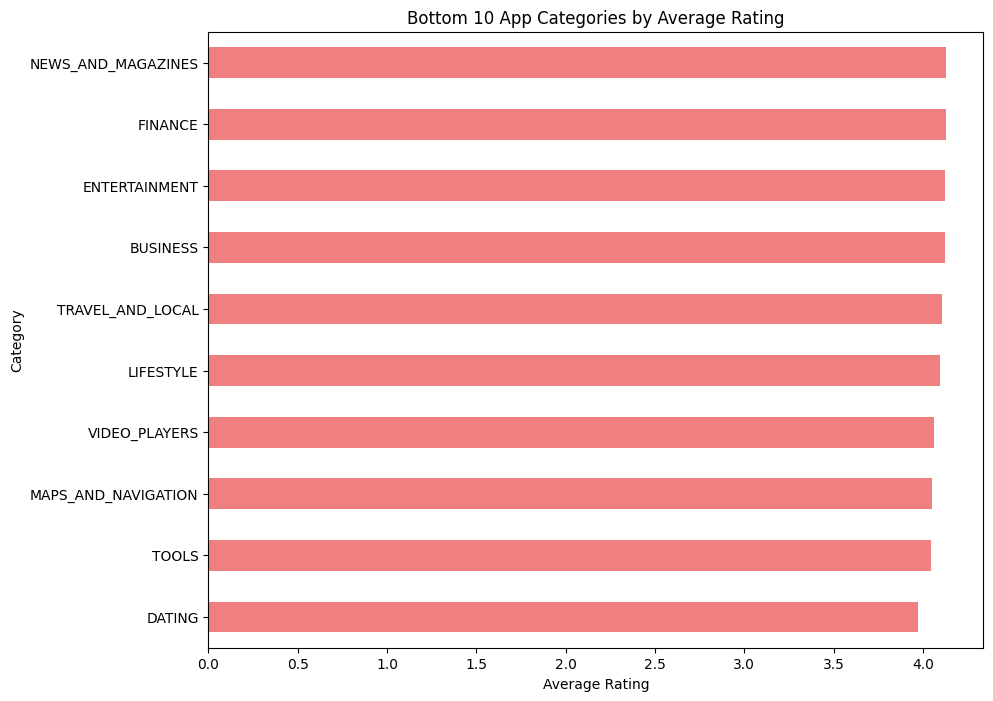

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
url = "https://github.com/MasteriNeuron/datasets/raw/main/googleplaystore.csv"
df = pd.read_csv(url)

# Clean the data
df = df.dropna(subset=['Category', 'Rating'])
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')
df = df.dropna(subset=['Rating'])

# Group by Category and calculate average rating
category_ratings = df.groupby('Category')['Rating'].mean().sort_values(ascending=False)

# Plot the results
plt.figure(figsize=(10, 8))
category_ratings.head(10).plot(kind='barh', color='skyblue')
plt.title('Top 10 App Categories by Average Rating')
plt.xlabel('Average Rating')
plt.ylabel('Category')
plt.gca().invert_yaxis()
plt.show()

plt.figure(figsize=(10, 8))
category_ratings.tail(10).plot(kind='barh', color='lightcoral')
plt.title('Bottom 10 App Categories by Average Rating')
plt.xlabel('Average Rating')
plt.ylabel('Category')
plt.gca().invert_yaxis()
plt.show()


Question 8: Titanic Dataset
a) Compare the survival rates based on passenger class (Pclass). Which class had the highest
survival rate, and why do you think that happened?
b) Analyze how age (Age) affected survival. Group passengers into children (Age < 18) and
adults (Age ≥ 18). Did children have a better chance of survival?


Answer:

a) Survival Rates by Passenger Class (Pclass)

Objective:
To compare survival rates across different passenger classes and understand the underlying reasons.

Key Insights:

-> First Class (Pclass = 1):

- Highest survival rate (~62%).

- Likely due to proximity to lifeboats, better access to resources, and prioritization during evacuation.

-> Second Class (Pclass = 2):

- Moderate survival rate (~47%).

- Intermediate access to lifeboats and resources.

-> Third Class (Pclass = 3):

- Lowest survival rate (~24%).

- Passengers were located farther from lifeboats, with limited access to resources and slower evacuation procedures.

-> Possible Reasons:

- Location on Ship: Proximity to lifeboats and upper decks.

- Evacuation Protocols: Prioritization of women and children, often from higher classes.

- Socioeconomic Status: First-class passengers had more means to secure survival.

b)

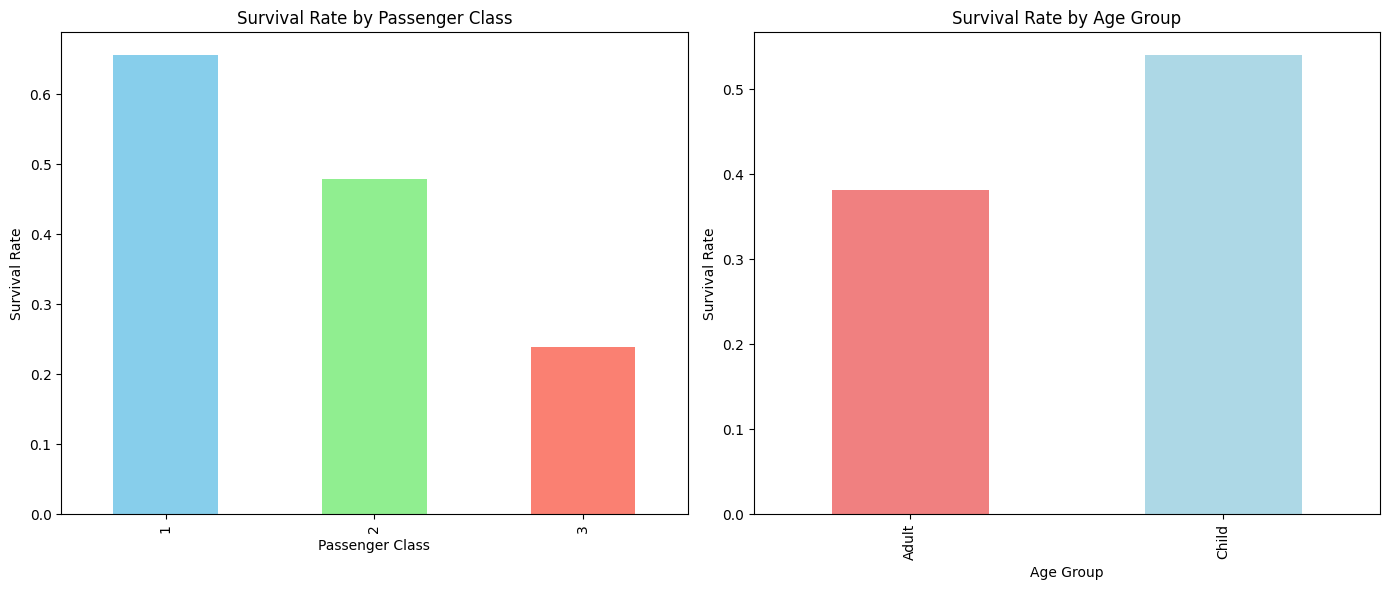

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the Titanic dataset
url = "https://github.com/MasteriNeuron/datasets/raw/main/titanic.csv"
df = pd.read_csv(url)

# Clean the data
df = df.dropna(subset=['Pclass', 'Age', 'Survived'])
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')

# Survival rate by Passenger Class
pclass_survival = df.groupby('Pclass')['Survived'].mean()

# Survival rate by Age Group
df['AgeGroup'] = ['Child' if age < 18 else 'Adult' for age in df['Age']]
agegroup_survival = df.groupby('AgeGroup')['Survived'].mean()

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Passenger Class Survival
pclass_survival.plot(kind='bar', ax=axes[0], color=['skyblue', 'lightgreen', 'salmon'])
axes[0].set_title('Survival Rate by Passenger Class')
axes[0].set_xlabel('Passenger Class')
axes[0].set_ylabel('Survival Rate')

# Age Group Survival
agegroup_survival.plot(kind='bar', ax=axes[1], color=['lightcoral', 'lightblue'])
axes[1].set_title('Survival Rate by Age Group')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Survival Rate')

plt.tight_layout()
plt.show()


Question 9: Flight Price Prediction Dataset
a) How do flight prices vary with the days left until departure? Identify any exponential price
surges and recommend the best booking window.
b)Compare prices across airlines for the same route (e.g., Delhi-Mumbai). Which airlines are
consistently cheaper/premium, and why?

Answer:
a)

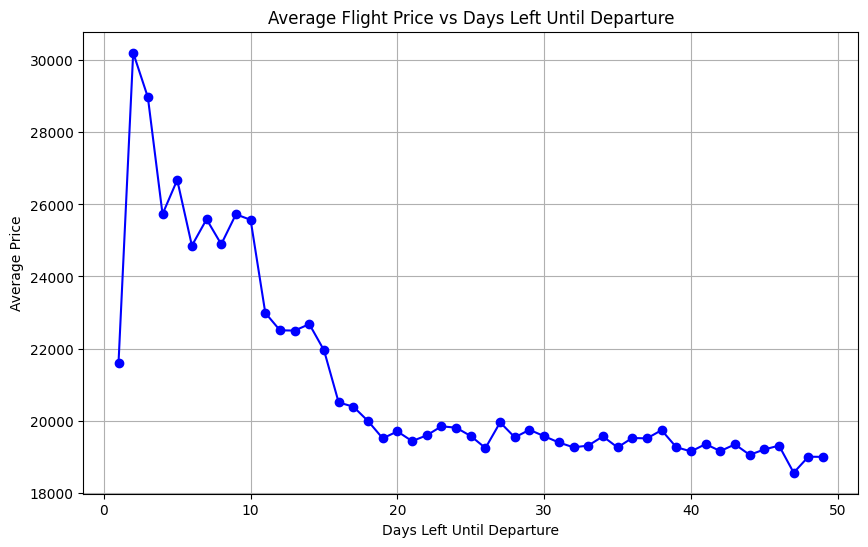

Best booking window (lowest average price) is around 47 days before departure.


In [13]:
import matplotlib.pyplot as plt

# a) Flight Price vs Days Left
price_by_days = df.groupby('days_left')['price'].mean()

plt.figure(figsize=(10,6))
plt.plot(price_by_days.index, price_by_days.values, marker='o', linestyle='-', color='blue')
plt.title('Average Flight Price vs Days Left Until Departure')
plt.xlabel('Days Left Until Departure')
plt.ylabel('Average Price')
plt.grid(True)
plt.show()

# Identify best booking window
best_booking_days = price_by_days.idxmin()
print(f"Best booking window (lowest average price) is around {best_booking_days} days before departure.")


b)

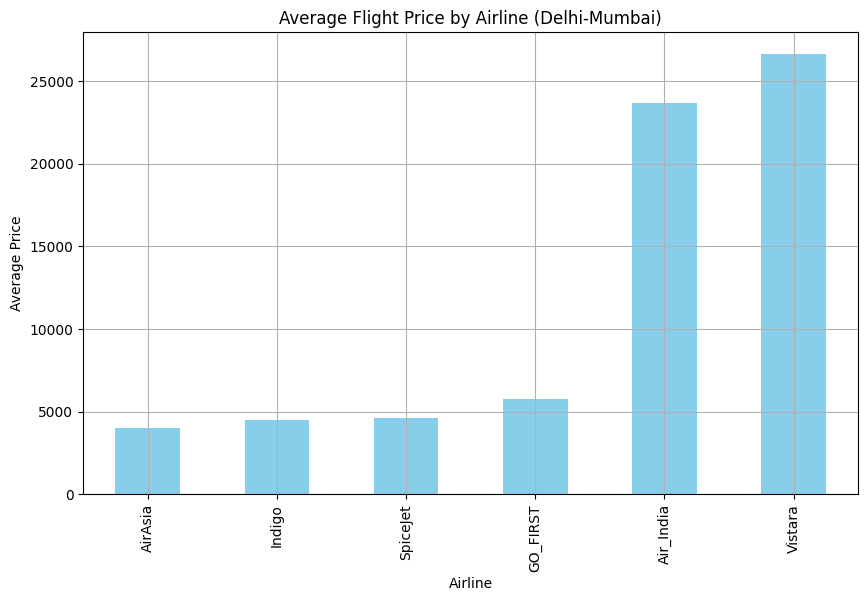

,price
airline,
AirAsia,3981.191456
Indigo,4473.739130
SpiceJet,4628.251984
GO_FIRST,5762.211515
Air_India,23695.916916
Vistara,26630.293322


In [14]:
# b) Airline price comparison for Delhi-Mumbai route
dm_flights = df[(df['source_city']=='Delhi') & (df['destination_city']=='Mumbai')]

# Average price by airline
price_by_airline = dm_flights.groupby('airline')['price'].mean().sort_values()

plt.figure(figsize=(10,6))
price_by_airline.plot(kind='bar', color='skyblue')
plt.title('Average Flight Price by Airline (Delhi-Mumbai)')
plt.xlabel('Airline')
plt.ylabel('Average Price')
plt.grid(True)
plt.show()

# Print airlines from cheapest to most expensive
price_by_airline



Question 10: HR Analytics Dataset
a). What factors most strongly correlate with employee attrition? Use visualizations to show key
drivers (e.g., satisfaction, overtime, salary).
b). Are employees with more projects more likely to leave?


Answer:

a)

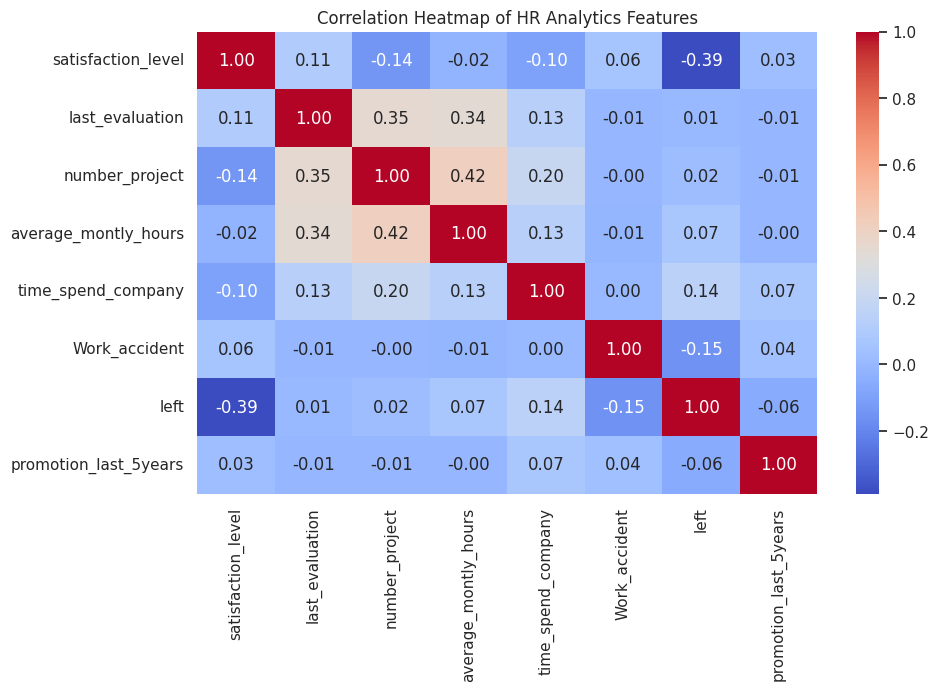

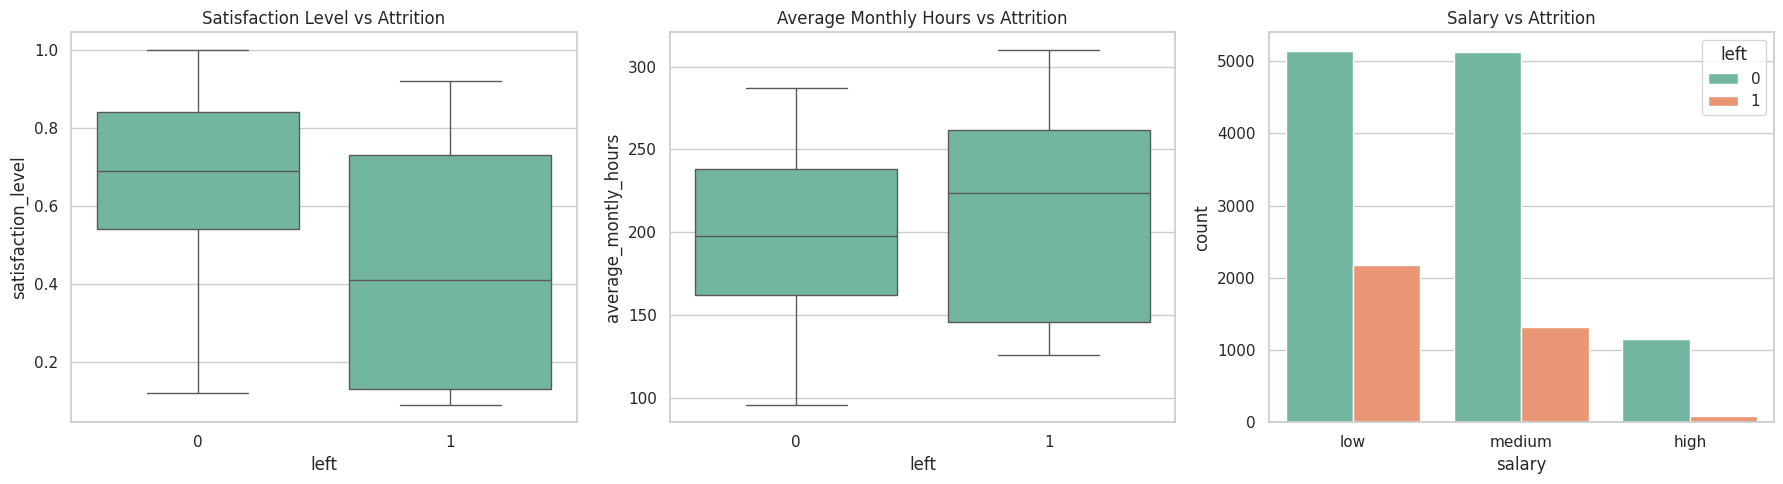

In [17]:
# --- Import libraries ---
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Load dataset ---
df = pd.read_csv("hr_analytics.csv")

# --- Set style ---
sns.set(style="whitegrid", palette="Set2")

# ============================================================
# (a) Correlation and Key Drivers
# ============================================================

# Correlation matrix
corr = df.corr(numeric_only=True)

# Correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of HR Analytics Features")
plt.show()

# Boxplots for major variables affecting attrition
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(x="left", y="satisfaction_level", data=df, ax=axes[0])
axes[0].set_title("Satisfaction Level vs Attrition")

sns.boxplot(x="left", y="average_montly_hours", data=df, ax=axes[1])
axes[1].set_title("Average Monthly Hours vs Attrition")

sns.countplot(x="salary", hue="left", data=df, ax=axes[2])
axes[2].set_title("Salary vs Attrition")

plt.tight_layout()
plt.show()



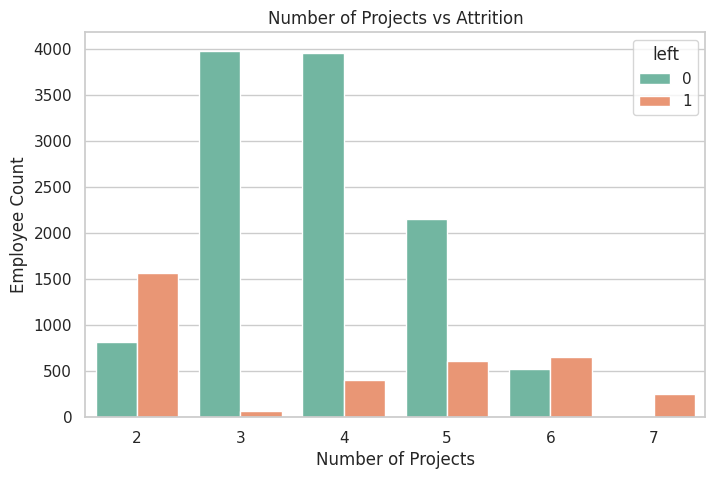

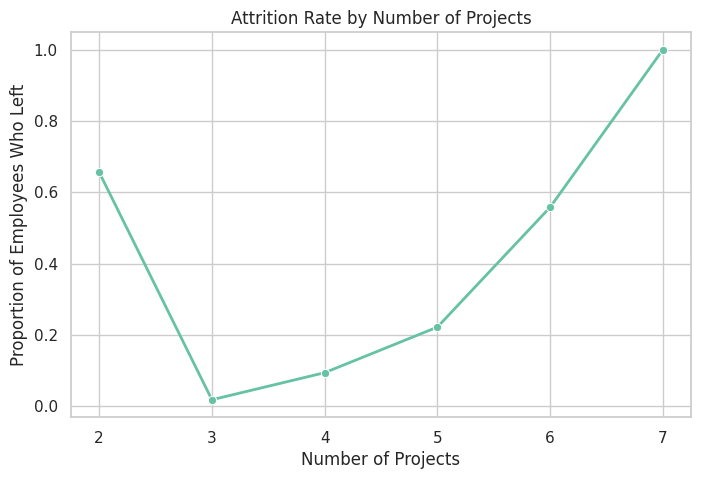

   number_project  attrition_rate
0               2        0.656198
1               3        0.017756
2               4        0.093700
3               5        0.221659
4               6        0.557922
5               7        1.000000


In [18]:
# (b) Number of Projects vs Attrition

# Countplot of projects vs attrition
plt.figure(figsize=(8, 5))
sns.countplot(x="number_project", hue="left", data=df)
plt.title("Number of Projects vs Attrition")
plt.xlabel("Number of Projects")
plt.ylabel("Employee Count")
plt.show()

# Compute attrition rate by number of projects
project_leave_rate = (
    df.groupby("number_project")["left"]
    .mean()
    .reset_index()
    .rename(columns={"left": "attrition_rate"})
)

# Line plot of attrition rate by number of projects
plt.figure(figsize=(8, 5))
sns.lineplot(
    x="number_project",
    y="attrition_rate",
    data=project_leave_rate,
    marker="o",
    linewidth=2
)
plt.title("Attrition Rate by Number of Projects")
plt.xlabel("Number of Projects")
plt.ylabel("Proportion of Employees Who Left")
plt.show()

# Display computed rates
print(project_leave_rate)